In [3]:
import pandas as pd
from matplotlib import pyplot as plt

fp = "/playpen/mufan/levi/tianlong-chen-lab/material-super-resolution/__exps__/1. p(z | X)/2024-12-14_18-08-05_simple_z_reg_vit/results.csv"
df = pd.read_csv(fp)
df.head()

,global_train_step,global_val_step,epoch,train_loss,val_loss,z
0,0.0,NaN,0,0.333393,NaN,0.000000
1,1.0,NaN,0,0.347689,NaN,0.000000
2,2.0,NaN,0,0.327514,NaN,0.000031
3,3.0,NaN,0,0.308728,NaN,0.001877
4,4.0,NaN,0,0.459625,NaN,0.599380


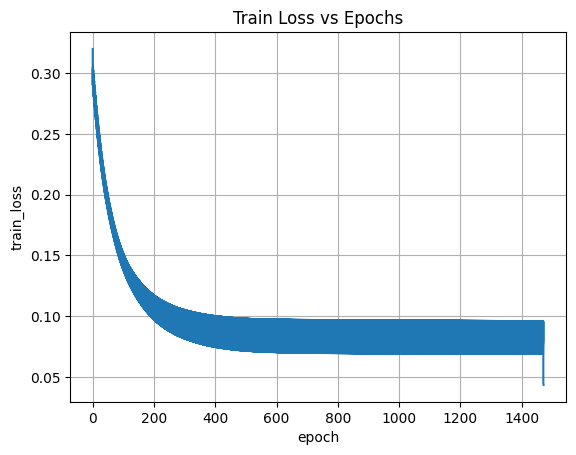

In [4]:
from matplotlib import pyplot as plt
from scipy.ndimage import gaussian_filter1d

SIGMA = 5

_df = df[df["global_train_step"].notna()]
train_steps = _df["epoch"]
train_losses = _df["train_loss"]
train_losses_smoothed = gaussian_filter1d(train_losses, sigma=SIGMA)

# plt.plot(train_steps, train_losses)
plt.plot(train_steps, train_losses_smoothed)
plt.xlabel("epoch")
plt.ylabel("train_loss")
plt.title("Train Loss vs Epochs")
plt.grid()
plt.show()

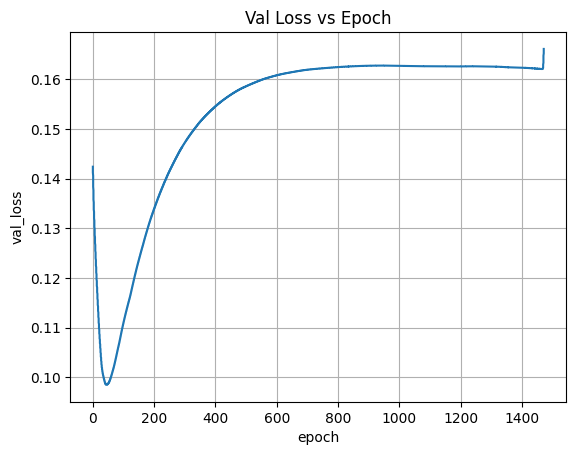

In [5]:
# plot val_loss vs. global_val_step
_df = df[df["global_val_step"].notna()]

val_steps = _df["epoch"]
val_losses = _df["val_loss"]
val_losses_smoothed = gaussian_filter1d(val_losses, sigma=SIGMA)

# plt.plot(val_steps, val_losses)
plt.plot(val_steps, val_losses_smoothed)
plt.xlabel("epoch")
plt.ylabel("val_loss")
plt.title("Val Loss vs Epoch")
plt.grid()
plt.show()

In [6]:
import numpy as np

f"{(np.mean(train_losses[-500: ]) * 100):.5f}%", f"{(np.mean(val_losses[-500: ])):.5f}%"

('8.18628%', '0.16228%')

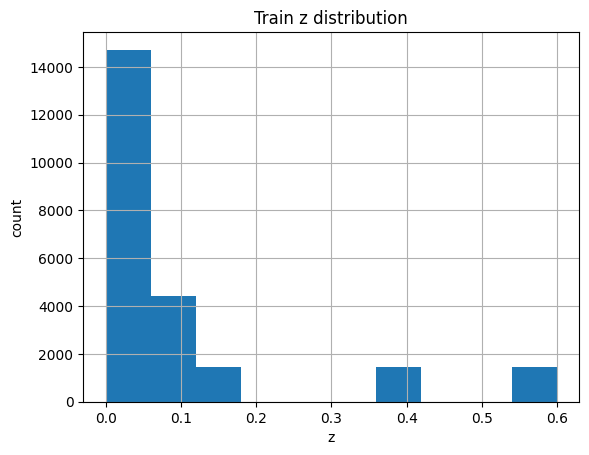

mean: 0.08363368652613255
std: 0.16247151694159595


In [7]:
_df = df[~df['global_val_step'].notnull()]
zs = _df["z"]

# plot a histogram of z
plt.hist(zs)
plt.xlabel("z")
plt.ylabel("count")
plt.title("Train z distribution")
plt.grid()
plt.show()

# show on figure mean and std of zs
print(f"mean: {zs.mean()}")
print(f"std: {zs.std()}")

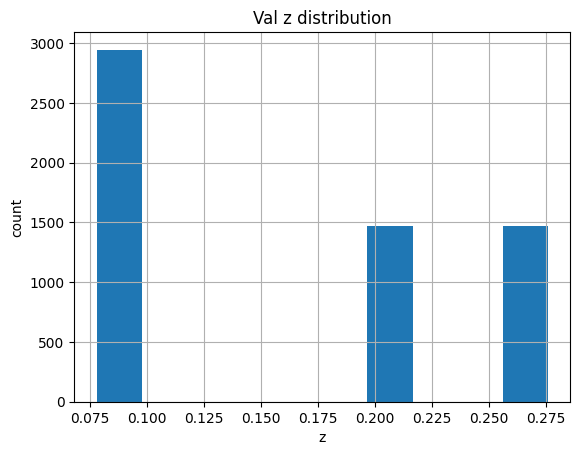

mean: 0.16519546508789062
std: 0.08234048821612851


In [8]:
_df = df[df['global_val_step'].notnull()]
zs = _df["z"]

# plot a histogram of z
plt.hist(zs)
plt.xlabel("z")
plt.ylabel("count")
plt.title("Val z distribution")
plt.grid()
plt.show()

# show on figure mean and std of zs
print(f"mean: {zs.mean()}")
print(f"std: {zs.std()}")

In [9]:
import math

# Given mean and standard deviation
mean = zs.mean()
std_dev = zs.std()

# Calculate MAE using the formula for a normal distribution
mae = std_dev * math.sqrt(2 / math.pi)

print(f"MAE of always predicting the mean: {mae * 100:.5f}%")

MAE of always predicting the mean: 6.56982%
